HISTORIA

PEQUEÑA EMPRESA DE TECNOLOGIA QUE QUIERE COMPRENDER CUAL ES LA COMPOSICION DEMOGRAFICA QUE TIENEN SUS USARIOS PARA PODER AJUSTAR DESPUES SUS ESTRATEGIAS DE MARKETING

ENTONCES COMO ING DE DATOS, EL OBJETIVO ES HACER UN ANALISIS EXPLORATORIO UNIVARIADO SOBRE 2 VARIABLES, QUE SERIA LAS VARIABLE DE EDAD Y LA DE INGRESOS ANUALES, VEREMOS CUAL ES LA COMPOSICION DEMOGRAFICA, COMO SE COMPORTA CADA UNA DE LAS VARIABLES Y AL FINAL CUAL SERIA EL PERFIL DE ESE COMPRADOR O DE ESE USUARIO QUE TIENE ESTA EMPRESA

ENTONCES VAMOS A CALCULAR LAS METRICAS DE TENDENCIA CENTRAL Y DE DISPERSION Y LUEGO VAMOS A EVALUAR LA FORMA DE DISTRIBUCION MEDIANTE LAS HERRAMIENTAS VISUALES(HISTOGRAMA Y BOXPLOT) Y POR ULTIMO VAMOS A REDACTAR UN INFORME TECNICO DONDE YA EXPLICA QUE SIGNICA CADA DATO

    Cliente_id  Edades   Ingresos
0     USR-0001      39   40955.62
1     USR-0002      33   36144.54
2     USR-0003      41   26005.17
3     USR-0004      50  122654.89
4     USR-0005      32   38270.83
..         ...     ...        ...
495   USR-0496      40   43496.86
496   USR-0497      24   39098.41
497   USR-0498      33   49930.51
498   USR-0499      26   19317.35
499   USR-0500      21   68188.66

[500 rows x 3 columns]
Resumen estadistico de las variables numericas (EDAD, INGRESOS)


Variable: Edades
Media (Promedio): 34.68
Mediana: 35.00
Moda: 35.00
Desviacion estandar: 9.51
Porcentaje de desvacion estandar: 27.41%
Varianza: 90.35
Cuartil 1 (Q1-25%): 27.75
Cuartil 3 (Q1-75%): 41.00
Rango intercuartilico  (IQR): 13.25
Coeficiente de sesgo: 0.33
Cursosis: -0.09

Variable: Ingresos
Media (Promedio): 40084.42
Mediana: 32544.97
Moda: 15116.07
Desviacion estandar: 24692.81
Porcentaje de desvacion estandar: 61.60%
Varianza: 609734628.55
Cuartil 1 (Q1-25%): 21740.28
Cuartil 3 (Q1-75%

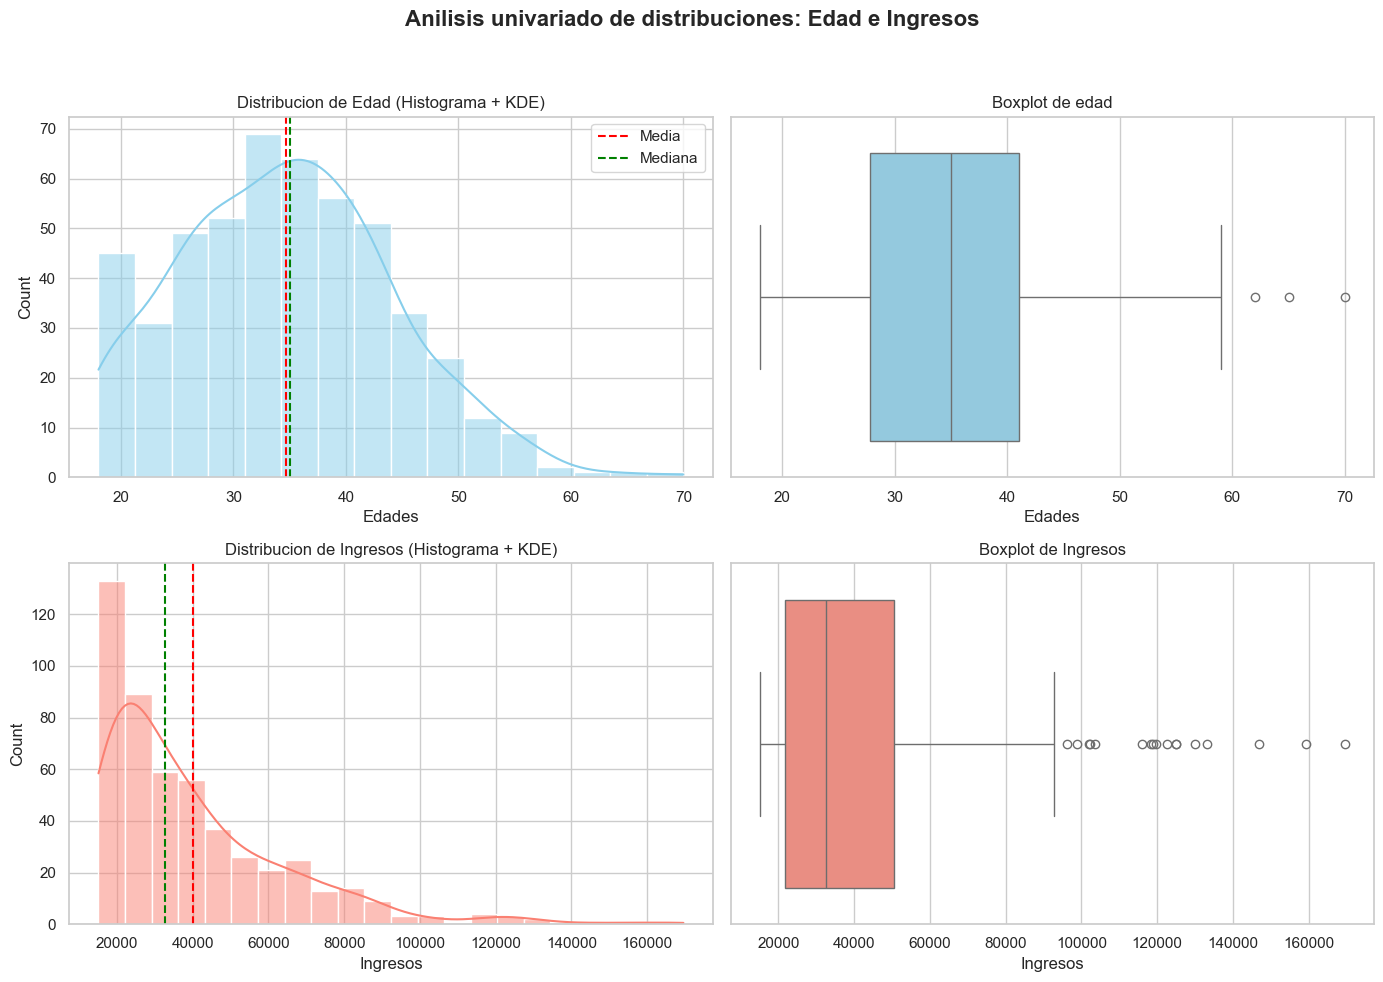

In [ ]:
#hacer anlisis exploratorio univariado de 2 variables, de edad y ingresos variados,r

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#configuracion visual de seaborn
sns.set_theme(style="whitegrid")#establece el tema que usara grafico, fondo blanco, lineas cuadricular 
#dataset de clientes
np.random.seed(42)
#genera 500 edades, loc media de las edades 35 años, scale - desviacion estandar de 10 años, astype - convierte los resultado decimales en numeros enteros
edades=np.random.normal(loc=35,scale=10,size=500).astype(int)
edades=np.clip(edades,18,70)#np clip hace limitar todas las edades que esten entre 18 y 70 anios
ingresos=np.random.exponential(scale=25000,size=500)+15000#el exponencial genera 500 ingresos simulados con una distribucion exponencial, +15000 suma s todos los valores 
#dataframe
df_clientes=pd.DataFrame({
    
    'Cliente_id':[f"USR-{i:04d}" for i in range(1,501)],#genera id de los 500 usuarios 
    'Edades':edades,
    'Ingresos':np.round(ingresos,2)#2 decimales
    

})

print(df_clientes)

#analsis estadistica de las variables numericas
print("Resumen estadistico de las variables numericas (EDAD, INGRESOS)")
print()
def calcular_estadisticas_univariadas(df,columna):
    media=df[columna].mean()
    mediana=df[columna].median()
    moda=df[columna].mode().iloc[0]
    std=df[columna].std()#desviacion estandar
    porcentaje_std=(std/media)*100#AGREGADO MIO
    var=df[columna].var()#varianza
    q1=df[columna].quantile(0.25)#primer cuartil
    q3=df[columna].quantile(0.75)#tercer cuartil
    iqr=q3-q1
    sesgo=df[columna].skew()
    curtosis=df[columna].kurt()
    print()
    print(f"Variable: {columna}")
    print(f"Media (Promedio): {media:.2f}")
    print(f"Mediana: {mediana:.2f}")
    print(f"Moda: {moda:.2f}")
    print(f"Desviacion estandar: {std:.2f}")
    print(f"Porcentaje de desvacion estandar: {porcentaje_std:.2f}%")#AGREGADO MIO
    print(f"Varianza: {var:.2f}")
    print(f"Cuartil 1 (Q1-25%): {q1:.2f}")
    print(f"Cuartil 3 (Q1-75%): {q3:.2f}")
    print(f"Rango intercuartilico  (IQR): {iqr:.2f}")
    print(f"Coeficiente de sesgo: {sesgo:.2f}")
    print(f"Cursosis: {curtosis:.2f}")
    
calcular_estadisticas_univariadas(df_clientes,"Edades")
calcular_estadisticas_univariadas(df_clientes,"Ingresos")
    
    
#visualizacion
print()
print("Visualizacion con histograma y Boxplot")
print()

fig,axes=plt.subplots(2,2,figsize=(14,10))
fig.suptitle('Anilisis univariado de distribuciones: Edad e Ingresos',fontsize=16,fontweight='bold')

#histograma edad
sns.histplot(df_clientes['Edades'],kde=True,ax=axes[0,0],color='skyblue')
axes[0,0].set_title('Distribucion de Edad (Histograma + KDE)')
axes[0,0].axvline(df_clientes['Edades'].mean(),color='red',linestyle='--',label='Media')
axes[0,0].axvline(df_clientes['Edades'].median(),color='green',linestyle='--',label='Mediana')
axes[0,0].legend()
#boxplot de edad
sns.boxplot(x=df_clientes['Edades'],ax=axes[0,1],color='skyblue')
axes[0,1].set_title('Boxplot de edad')

#histograma de ingresos
sns.histplot(df_clientes['Ingresos'],kde=True,ax=axes[1,0],color='salmon')
axes[1,0].set_title('Distribucion de Ingresos (Histograma + KDE)')
axes[1,0].axvline(df_clientes['Ingresos'].mean(),color='red',linestyle='--',label='Media')
axes[1,0].axvline(df_clientes['Ingresos'].median(),color='green',linestyle='--',label='Mediana')
axes[0,0].legend()
#boxplot de ingresos
sns.boxplot(x=df_clientes['Ingresos'],ax=axes[1,1],color='salmon')
axes[1,1].set_title('Boxplot de Ingresos')

plt.tight_layout(rect=[0,0,1,0.95])#evita que la graficas se superpongan
plt.show()

Analisis Tecnico 

El analisis univariado de la muestra representa 2 comportamientos distintos entre las variables analizadas

VARIABLE EDAD ANALISIS:

La variable edad presenta una distribucion simetrica con un coeficiente de sesgo de 0.33, con una media de 35 y una mediana de 35 años, coincide casi a la perfeccion, significa poca presencia de outliers que se pueden ver en el diagrama de boxplot

La variable de ingresos muestra una asimetria fuerte y un claro sesgo a la derecha con un coeficiente de sesgo que es elevado de 1.77, esa simetria esta desplazando la media a la derecha con respecto a la mediana, dada por un grupo reducido de usuarios con ingresos atipicos que superan los 100000$, visibles en el boxplot


PERFIL DEL USAURIO PROMEDIO:

Edad tipica de 35 años, con un 50% de la poblacion concentrada entre los 28 y 41 años de edad
Un ingreso mediano de 32544.97$

Si se quiere tomar una decision sobre precios, se recomienda usar la mediana como metrica de ingresos ya que la media esta distorcionada por los valores atipocos
